# Empirical Study of the Online Extra Trees (OXT) Regressor

Assignment devoloped by António Romão (up202108704) and Bruno Moreira (up202107143) for the Data Stream Mining course at FEUP.


## Table of Contents

1. [Introduction and Objectives](#1-introduction-and-objectives)
    - 1.1. [Context and Problem Statement](#11-context-and-problem-statement)
    - 1.2. [Assignment Objectives](#12-assignment-objectives)
2. [Instructions for Reproducibility](#2-instructions-for-reproducibility)
3. [Algorithms Overview: OXT and Baseline Regressors](#3-algorithms-overview-oxt-and-baseline-regressors)
    - 3.1. [Online Extra Trees (OXT)](#31-online-extra-trees-oxt)
    - 3.2. [Baseline Models for Comparison](#32-baseline-models-for-comparison)
4. [Datasets](#4-datasets)
    - 4.1. [Specification and Sources](#41-specification-and-sources)
    - 4.2. [Stream Characterization & Visualizing Concept Drift](#42-stream-characterization--visualizing-concept-drift)
5. [Parameter and Hyperparameter Settings](#5-parameter-and-hyperparameter-settings)
6. [Empirical Evaluation Execution](#6-empirical-evaluation-execution)
    - 6.1. [Core Evaluator](#61-core-evaluator)
    - 6.2. [Hyperparameter Search](#62-hyperparameter-search)
    - 6.3. [Tuning Observations](#63-tuning-observations)
7. [Results Analysis and Discussion](#7-results-analysis-and-discussion)
    - 7.1. [Predictive Performance (Accuracy Analysis)](#71-predictive-performance-accuracy-analysis)
    - 7.2. [Resource Efficiency and Computational Cost](#72-resource-efficiency-and-computational-cost)
    - 7.3. [Concept Drift Adaptation and Recovery](#73-concept-drift-adaptation-and-recovery)
8. [Strengths, Limitations, and Conclusions](#8-strengths-limitations-and-conclusions)
9. [References](#9-references)

## 1. Introduction and Objectives

[[go back to top]](#table-of-contents)

This section establishes the foundation for our empirical study of the Online Extra Trees (OXT) regressor. Conducted as part of the Data Stream Mining course's first practical assignment, this study evaluates the OXT algorithm's ability to handle continuous data streams. Before detailing the experimental setup and results, we first define the core problem context and outline the primary objectives guiding our comparative analysis.

### 1.1. Context and Problem Statement

[[go back to section]](#1-introduction-and-objectives)

In traditional machine learning, models are typically trained on static, bounded datasets where multiple passes over the data are possible. However, in many modern applications, data is generated continuously and must be processed sequentially. This paradigm, known as Data Stream Mining, introduces significant challenges: algorithms must learn incrementally (usually in a single pass), operate under strict memory and computational time constraints, and continuously adapt to potential shifts in the underlying data distribution, known as concept drift.

This empirical study focuses on the specific problem of regression within a data stream setting. To address this, we evaluate the Online Extra Trees (OXT) regressor. The OXT algorithm is an ensemble learning method adapted for streaming data, designed to incrementally update a forest of randomized decision trees as new continuous target variables arrive. By analyzing OXT, we aim to understand how ensemble methods can effectively maintain predictive performance while adhering to the strict resource limitations of streaming environments.

### 1.2. Assignment Objectives

[[go back to section]](#1-introduction-and-objectives)

The overarching goal of this assigment is to perform a comprehensive empirical analysis of a specific data stream algorithm: in our case, the Online Extra Trees (OXT) regressor.

To achieve this, our study is guided by the following core objectives:
* **Understand the Algorithm:** Thoroughly investigate the OXT regressor to understand its underlying mechanics, state management, and theoretical assumptions in a streaming context.
* **Design a Reproducible Evaluation:** Develop and execute an informative and fully reproducible empirical evaluation comparing the OXT regressor against a chosen baseline comparison algorithm, utilizing at least two distinct datasets.
* **Critically Analyze Results:** Evaluate the experimental outcomes to identify the specific strengths and limitations of the OXT algorithm under varying streaming conditions.

## 2. Instructions for Reproducibility

[[go back to top]](#table-of-contents)

To ensure full reproducibility of this empirical evaluation, please set up an isolated virtual environment. This project was developed and tested using **Python 3.11**.

**Step-by-Step Guide:**
1. **Navigate to the directory:** Open your terminal and travel to the root of this project.
2. **Create the virtual environment:** Run `python3 -m venv dsm_env`
3. **Activate the environment:**
   * On macOS/Linux: `source dsm_env/bin/activate`
   * On Windows: `dsm_env\Scripts\activate`
4. **Install dependencies:** Run `pip install -r requirements.txt`
5. **Register the Jupyter Kernel:** Run `python -m ipykernel install --user --name=dsm_env --display-name "Python (DSM OXT)"`
6. **Execute:** Open this notebook, ensure the "Python (DSM OXT)" kernel is selected, and run all cells sequentially.

## 3. Algorithms Overview: OXT and Baseline Regressors

[[go back to top]](#table-of-contents)

This section outlines the theoretical foundations of the proposed Online Extra Trees algorithm and the selected baseline models. To rigorously evaluate the performance of OXT, we benchmark it against two established regressors: the Adaptive Random Forest (ARF) Regressor, serving as the "Gold Standard" state-of-the-art ensemble baseline, and the Hoeffding Tree Regressor (HTR), serving as the structural baseline for incremental tree learning.

### 3.1. Online Extra Trees (OXT)

[[go back to section]](#3-algorithms-overview-oxt-and-baseline-regressors)

The Online Extra Trees (OXT) algorithm is an adaptation of the batch Extremely Randomized Trees algorithm designed specifically for data stream mining. Traditional streaming tree ensembles compute the Hoeffding bound for every feature at every node to determine the optimal split, which is highly computationally expensive. OXT circumvents this bottleneck by strongly randomizing both the attribute selection and the split-point cutoffs. By evaluating only a random subset of features and a random split value for each, OXT drastically reduces the mathematical overhead required to grow the tree.

**State Management and Updates:** To operate in a single-pass streaming setting, OXT must incrementally maintain "state" at the leaf nodes rather than storing historical data. For continuous regression targets, each leaf tracks sufficient statistics—specifically, the instance count or sum of weights ($N$), the sum of target values ($\sum y$), and the sum of squared target values ($\sum y^2$). When a new instance arrives, it traverses the tree and updates these statistics at the corresponding leaf. Because OXT uses randomized split-points, it only tracks variance reduction metrics for a random subset of feature-cutoffs, skipping the exhaustive calculations required by traditional Hoeffding bounds to trigger a node split.

**Concept Drift Handling:**
To adapt to changing underlying data distributions, OXT actively monitors its predictive performance. Drift detectors (such as ADWIN) track the sequential error rates of the individual trees in the ensemble. When ADWIN detects a statistically significant increase in error (indicating concept drift), the obsolete tree is reset or replaced. This localized, tree-level adaptation allows the ensemble to seamlessly update its knowledge base without interrupting the stream processing.

**Hypothesis:** The primary hypothesis of this empirical evaluation is that OXT can leverage the ensemble effect to maintain high predictive accuracy while offering significant reductions in execution time and memory consumption compared to heavier streaming ensembles.

### 3.2. Baseline Models for Comparison

[[go back to section]](#3-algorithms-overview-oxt-and-baseline-regressors)

To contextualize the performance of OXT, it is evaluated against two distinct types of streaming regressors:

**The "Gold Standard" Ensemble: Adaptive Random Forest (ARF) Regressor**
* **Mechanism:** ARF is widely considered the state-of-the-art ensemble method for data streams. It adapts the traditional Random Forest by using online bagging (via Poisson distribution) to simulate bootstrapping. Crucially, ARF incorporates explicit drift detection (commonly ADWIN) to monitor the error rate of individual trees. When drift is detected, it trains "background trees" to seamlessly replace obsolete trees without interrupting the stream.
* **Rationale for Comparison:** ARF represents the ceiling for predictive performance in streaming ensembles. Comparing OXT to ARF isolates the trade-off between accuracy and resource efficiency. OXT must demonstrate that it can approximate or match ARF's error metrics (like MAE or RMSE) while proving superior in terms of memory footprint and processing speed.

**The Structural Baseline: Hoeffding Tree Regressor (HTR)**
* **Mechanism:** Also known in literature as the Fast Incremental Model Tree with Drift Detection (FIMT-DD), the Hoeffding Tree is the foundational single-tree architecture for online learning. It processes instances one by one, using the statistical Hoeffding bound to guarantee, with high probability, that a split made on a small sample of data is the exact same split that would be made if the tree had access to infinite data.
* **Rationale for Comparison:** HTR represents the absolute performance floor that an ensemble model must exceed. Because an ensemble introduces inherent computational complexity by managing multiple trees, it must yield a statistically significant improvement in predictive accuracy over a single, well-optimized Hoeffding Tree. If OXT cannot consistently outperform the HTR, the overhead of the ensemble architecture is not justified.

In [52]:
from river import forest
from river import tree
from river import drift
from river import metrics

oxt_example = forest.OXTRegressor(
    n_models=10,                              # number of trees used -> more trees -> more accuracy (plateaus)
    max_features="sqrt",                      # number of features evaluated at each split
    resampling_strategy="subbagging",         # how instances are passed to trees
    resampling_rate=0.5,                      # subbaging only, prob. of incoming instance being used by a tree
    detection_mode="all",                     # controls drift adaptation
    warning_detector=drift.ADWIN(delta=0.01), # statistical algorithms used to monitor error
    drift_detector=drift.ADWIN(delta=0.001),  # on ADWIN (standard) lower delta -> stricter threshold for drift
    max_depth=None,                           # limit tree growth to constraint memory
    randomize_tree_depth=False,               # unique to OXT, forces diff. depths across trees for diversity
    track_metric=metrics.MAE(),               # metric used to evaluate tree performance
    disable_weighted_vote=False               # have prediction weights based on internal tree metrics or just average
)

arf_example = forest.ARFRegressor(
    n_models=10,                              # same as above
    max_features="sqrt",                      # same as above
    aggregation_method="mean",                # how ensemble combine predictions
    warning_detector=drift.ADWIN(delta=0.01), # same as above
    drift_detector=drift.ADWIN(delta=0.001),  # same as above
    grace_period=50,                          # how many instances a leaf must observe before bound calculation for split
    delta=1e-7,                               # target for Hoeffding bound calculations
    tau=0.05,                                 # between two best features, split anyway if difference falls below threshold
    leaf_prediction="adaptive",               # how leaves make predictions
    seed=42                                   # random start seed
)

htr_example = tree.HoeffdingTreeRegressor(
    grace_period=200,                         # ensure solid calculation before split
    max_depth=None,                           # same as above
    delta=1e-7,                               # same as in ARF
    tau=0.05,                                 # same as in ARF
    leaf_prediction="adaptive",               # same as in ARF
    nominal_attributes=None                   # when you have label-encoded features, pass indices here
)

## 4. Datasets

[[go back to top]](#table-of-contents)

To comprehensively evaluate the OXT regressor, we utilize one synthetic and one real-world dataset, both designed for continuous regression tasks. Both datasets are sourced and loaded via the `river.datasets` API.

### 4.1. Specification and Sources


[[go back to section]](#4-datasets)

**1. Synthetic Data: The Friedman Generator**
We use the Friedman Generator (`river.datasets.synth.Friedman`) to simulate a complex, non-linear mathematical relationship between 10 features and a continuous target. Generating 100,000 instances allows for full experimental control and the explicit injection of concept drift to precisely measure the algorithms' adaptation and recovery mechanisms. We configure three distinct stream variations:
* **Stationary:** The baseline mathematical function remains constant.
* **Abrupt Drift:** At instance 50,000, the underlying function instantly changes by swapping the mathematical roles of specific features ($x_0$ with $x_4$, and $x_1$ with $x_3$).
* **Gradual Drift:** Using a sigmoid function centered around instance 50,000, the stream smoothly transitions between the original and the swapped-feature concepts over a window of 10,000 instances.

**2. Real-World Data: Bike Sharing**
For organic data, we use the Bike Sharing dataset (`river.datasets.Bikes`), originally sourced from the UCI Machine Learning Repository/OpenML. This dataset contains 182,470 instances and 8 features, recording the hourly count of rented bicycles in a city-share system alongside meteorological and temporal data. It is a highly cited data stream benchmark because it naturally embeds continuous environmental dynamics—such as recurring daily behaviors and gradual seasonal weather changes. It combines a manageable size for rapid iteration with sufficient feature richness to be deeply informative.

In [53]:
from river import datasets
from river.datasets import synth

import math
import random

# Synthetic: Friedman Generator

# -> generate and yield instance per call
def load_friedman_stationary(n_instances: int = 100_000, seed: int = 42):
    gen = synth.Friedman(seed=seed)

    for i, (x, y) in enumerate(gen):
        if i >= n_instances:
            break
        yield x, y

# same as above, with an abrupt drift
def load_friedman_with_abrupt_drift(n_instances: int = 100_000, drift_position: int = 50_000, seed: int = 42):
    rng = random.Random(seed)

    for i in range(n_instances):
        # 10 uniform features in [0, 1]
        features = {f"x{j}": rng.uniform(0, 1) for j in range(10)}

        noise = rng.gauss(0, 1)

        if i < drift_position:
            # original function for friedman
            y = (
                10 * math.sin(math.pi * features["x0"] * features["x1"])
                + 20 * (features["x2"] - 0.5) ** 2
                + 10 * features["x3"]
                + 5 * features["x4"]
                + noise
            )
        else:
            # drifted function, swap roles (x0↔x4, x1↔x3)
            y = (
                10 * math.sin(math.pi * features["x4"] * features["x3"])
                + 20 * (features["x2"] - 0.5) ** 2
                + 10 * features["x1"]
                + 5 * features["x0"]
                + noise
            )

        yield features, y

# same as above, with gradual drift
def load_friedman_with_gradual_drift(n_instances: int = 100_000, drift_center: int = 50_000, drift_width: int = 10_000, seed: int = 42):
    rng = random.Random(seed)

    # controls sigmoid function, scaling
    # to be balanced with drift_window
    steepness = 12.0 / max(drift_width, 1)

    for i in range(n_instances):
        # 10 uniform features in [0, 1]
        features = {f"x{j}": rng.uniform(0, 1) for j in range(10)}
        noise = rng.gauss(0, 1)
 
        # original Friedman function
        y_a = (
            10 * math.sin(math.pi * features["x0"] * features["x1"])
            + 20 * (features["x2"] - 0.5) ** 2
            + 10 * features["x3"]
            + 5 * features["x4"]
            + noise
        )
 
        # swapped feature roles (x0↔x4, x1↔x3)
        y_b = (
            10 * math.sin(math.pi * features["x4"] * features["x3"])
            + 20 * (features["x2"] - 0.5) ** 2
            + 10 * features["x1"]
            + 5 * features["x0"]
            + noise
        )
 
        # sigmoid blending of two concepts
        p_new = 1.0 / (1.0 + math.exp(-steepness * (i - drift_center)))
 
        # blend the two targets smoothly
        y = (1 - p_new) * y_a + p_new * y_b
 
        yield features, y

# Real: Bike Sharing

# -> dataset gets loaded and cached
# -> each call yields an instance
def load_bikes():
    dataset = datasets.Bikes()
    for x, y in dataset:
        yield x, y

# return metadata about the dataset
def get_bikes_info():
    dataset = datasets.Bikes()
    return {
        "name": dataset.__class__.__name__,
        "n_instances": dataset.n_samples,
        "n_features": dataset.n_features,
        "task": str(dataset.task),
    }


### 4.2. Stream Characterization & Visualizing Concept Drift

[[go back to section]](#4-datasets)


In Data Stream Mining, traditional batch Exploratory Data Analysis (EDA)—such as computing static correlation matrices over an entire dataset—violates the fundamental assumption that data arrives sequentially and underlying concepts may change. 

Instead, we perform **Stream Characterization** by visualizing the target variable over time. This allows us to visually confirm the injected structural changes in our synthetic streams and the organic temporal dynamics of our real-world stream. 

> **Note:** To make the underlying concepts visible beneath the noise, the synthetic plots apply a rolling mean window of 500 instances, and the Bikes plot applies a 24-hour rolling mean.

Plotting Synthetic Streams...


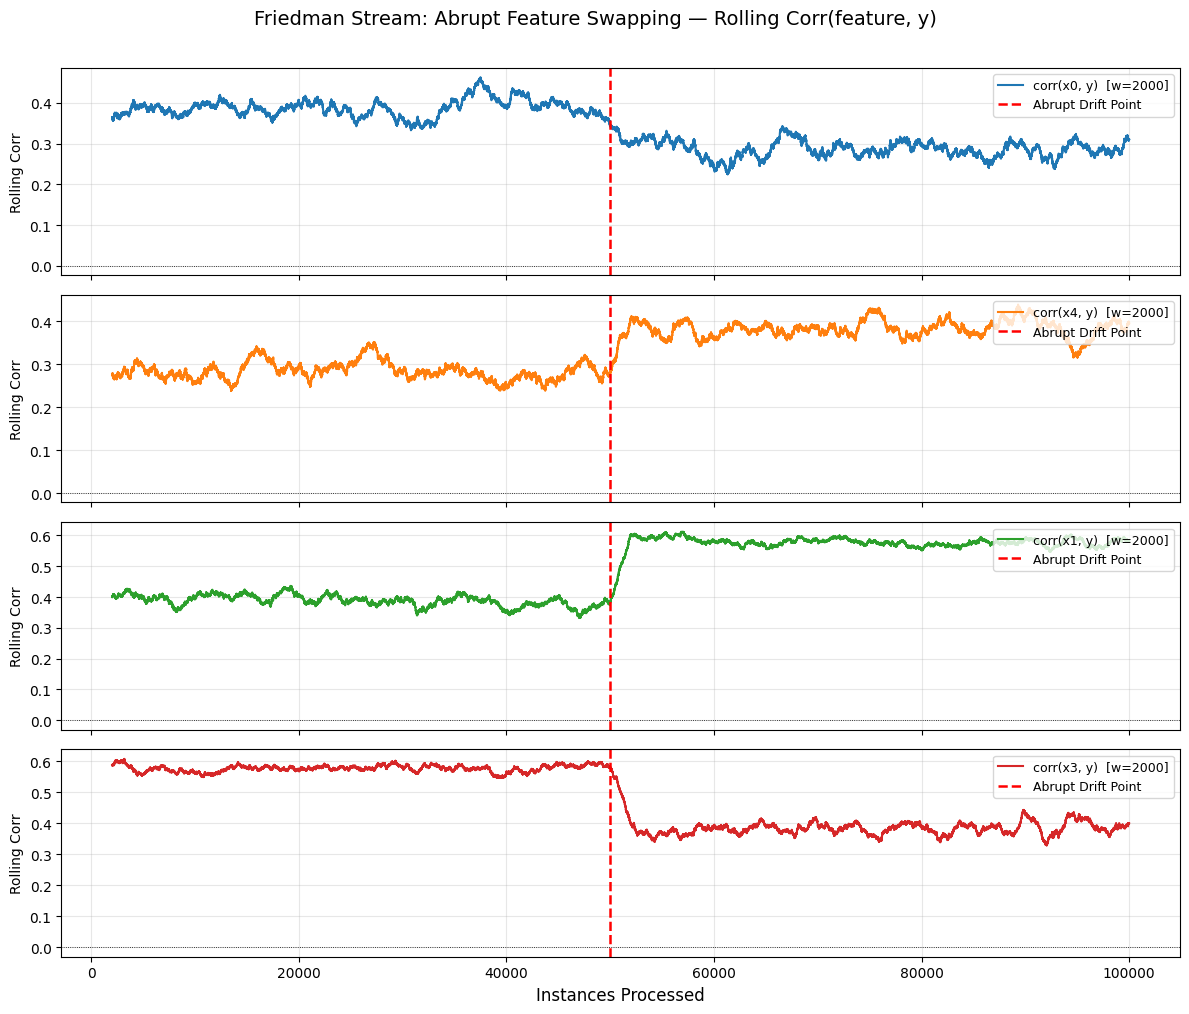

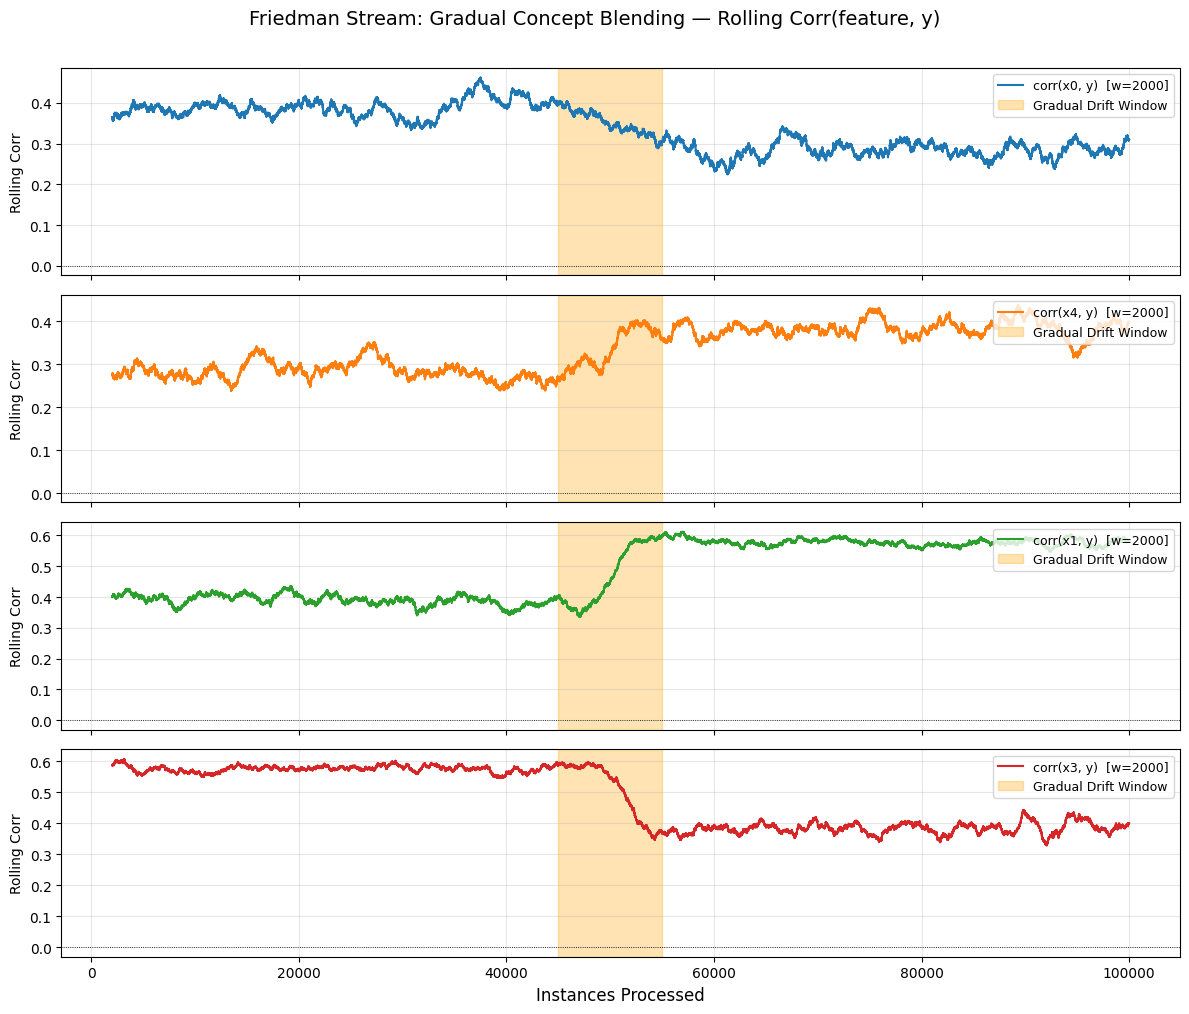

Plotting Organic Stream...


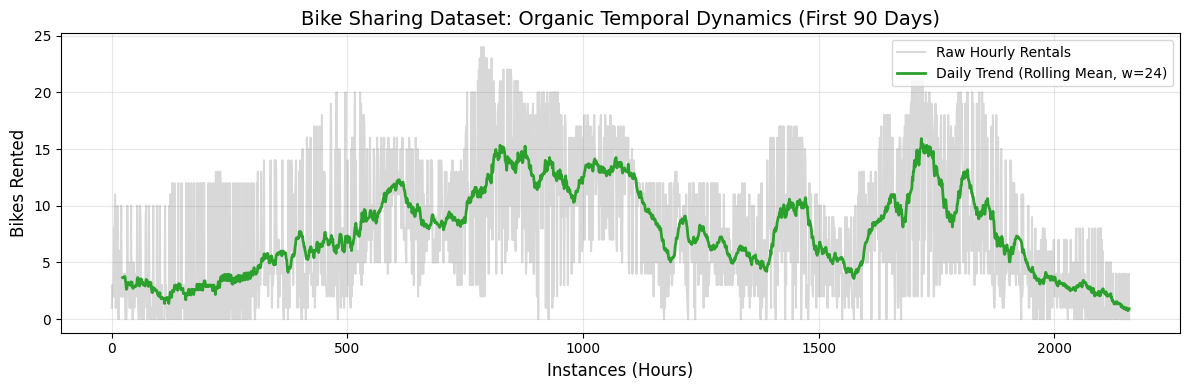

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
from river import datasets

# ---------------------------------------------------------
# 1. Visualize Synthetic Streams (Friedman)
# ---------------------------------------------------------
# NOTE: Plotting rolling mean of y cannot reveal this drift.
# The abrupt swap (x0<->x4, x1<->x3) preserves the marginal
# distribution of y because all features share the same U[0,1]
# distribution. Instead, we plot rolling feature-target correlations
# for the swapped pairs, which directly shows the concept change.

def plot_synthetic_stream(generator_func, title, drift_point=None,
                          drift_window=None,
                          features_to_watch=None,
                          corr_window=2000):
    """
    Visualizes concept drift in a Friedman stream by plotting rolling
    Pearson correlations between watched features and the target y.

    Parameters
    ----------
    generator_func     : callable — stream generator (yields x, y)
    title              : str     — plot title
    drift_point        : int     — instance index of drift centre
    drift_window       : int     — width of gradual drift window (None = abrupt)
    features_to_watch  : list   — feature names to track; defaults to the
                                  two swapped pairs ["x0","x4","x1","x3"]
    corr_window        : int     — rolling window size for correlation
    """
    if features_to_watch is None:
        features_to_watch = ["x0", "x4", "x1", "x3"]

    # --- collect stream ---
    records = []
    for x, y in generator_func(n_instances=100_000):
        row = {f: x[f] for f in features_to_watch}
        row["y"] = y
        records.append(row)
    df = pd.DataFrame(records)

    # --- one subplot per watched feature ---
    n = len(features_to_watch)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
    if n == 1:
        axes = [axes]

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    for ax, feat, color in zip(axes, features_to_watch, colors):
        roll_corr = df[feat].rolling(corr_window).corr(df["y"])
        ax.plot(roll_corr, color=color, linewidth=1.5,
                label=f"corr({feat}, y)  [w={corr_window}]")
        ax.axhline(0, color="black", linewidth=0.6, linestyle=":")

        # mark drift
        if drift_point is not None and drift_window is None:
            ax.axvline(x=drift_point, color="red", linestyle="--",
                       linewidth=1.8, label="Abrupt Drift Point")
        elif drift_point is not None and drift_window is not None:
            ax.axvspan(drift_point - drift_window / 2,
                       drift_point + drift_window / 2,
                       color="orange", alpha=0.3,
                       label="Gradual Drift Window")

        ax.set_ylabel("Rolling Corr", fontsize=10)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Instances Processed", fontsize=12)
    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


print("Plotting Synthetic Streams...")
plot_synthetic_stream(
    load_friedman_with_abrupt_drift,
    "Friedman Stream: Abrupt Feature Swapping — Rolling Corr(feature, y)",
    drift_point=50_000
)
plot_synthetic_stream(
    load_friedman_with_gradual_drift,
    "Friedman Stream: Gradual Concept Blending — Rolling Corr(feature, y)",
    drift_point=50_000, drift_window=10_000
)

# ---------------------------------------------------------
# 2. Visualize Real-World Stream (Bikes)  — unchanged
# ---------------------------------------------------------
def plot_bikes_stream(n_instances=24 * 30 * 3):  # ~3 months of hourly data
    dataset = datasets.Bikes()
    y_vals = []

    for i, (x, y) in enumerate(dataset):
        if i >= n_instances:
            break
        y_vals.append(y)

    plt.figure(figsize=(12, 4))

    # Plot raw hourly data with low alpha
    plt.plot(y_vals, color="gray", alpha=0.3, label="Raw Hourly Rentals")

    # Plot daily rolling mean to show the underlying trend
    s_daily = pd.Series(y_vals).rolling(window=24).mean()
    plt.plot(s_daily, color="#2ca02c", linewidth=2,
             label="Daily Trend (Rolling Mean, w=24)")

    plt.title("Bike Sharing Dataset: Organic Temporal Dynamics (First 90 Days)",
              fontsize=14)
    plt.xlabel("Instances (Hours)", fontsize=12)
    plt.ylabel("Bikes Rented", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Plotting Organic Stream...")
plot_bikes_stream()

## 5. Parameter and Hyperparameter Settings

[[go back to top]](#table-of-contents)

To ensure a fair algorithmic comparison between OXT and its baselines, we define a dedicated search grid for each algorithm (symmetric tuning, parameters get mirrored whenever shared) rather than only one for the proposed method. We also provide the same tuning budget (random-search configuration count) to each model. Specifically, we allocate a budget of 50 random search iterations per model.

OXT's grid spans the parameters that define its distinctive behaviour. ARF's grid mirrors OXT's wherever the parameters are shared, and adds `lambda_value` to cover Oza's online bagging versus Leveraging Bagging. HTR's grid is naturally smaller because HTR has fewer degrees of freedom, but it is tuned with the same random-search budget, which produces denser coverage of its (smaller) space.

A few parameters are left out, for principled reasons. OXT's `detection_mode` and the ADWIN $\delta$ values are fixed across configurations because the tuning stream is stationary; no drift signal exists there for the search to exploit. The same logic applies to ARF's drift and warning detectors. OXT's `randomize_tree_depth` is fixed to `False` to keep `max_depth` comparable across ensembles, and `disable_weighted_vote` is fixed to match ARF's `aggregation_method="mean"` so that differences in aggregation do not contaminate the ensemble-to-ensemble comparison.

In [55]:
OXT_GRID = {
    "n_models": [10, 25, 50],
    "max_features": ["sqrt", "log2", 0.5, None],
    "resampling_strategy": ["subbagging", "bagging"],
    "resampling_rate": [0.5, 0.75, 1],
    "leaf_prediction": ["mean", "model", "adaptive"],
    "grace_period": [50, 100, 200],
    "delta": [1e-7, 1e-3, 0.01],
    "max_depth": [None, 10, 20],
}

ARF_GRID = {
    "n_models": [10, 25, 50],
    "max_features": ["sqrt", "log2", 0.5, None],
    "lambda_value": [1, 6],
    "leaf_prediction": ["mean", "model", "adaptive"],
    "grace_period": [50, 100, 200],
    "delta": [1e-7, 1e-3, 0.01],
    "max_depth": [None, 10, 20],
}

HTR_GRID = {
    "grace_period": [50, 100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "delta": [1e-7, 1e-5, 1e-3, 0.01],
    "tau": [0.05, 0.1],
    "leaf_prediction": ["mean", "model", "adaptive"],
    "binary_split": [True, False],
}

GRIDS = {"OXT": OXT_GRID, "ARF": ARF_GRID, "HTR": HTR_GRID}

## 6. Empirical Evaluation Execution

[[go back to top]](#table-of-contents)

In this component, we use the Friedman-Stationary dataset to find each models best general-purpose configuration, to be evaluated on its own while it found the best parameters for each model, for said models then to be used in the three other use cases (Friedman-Abrupt, Friedman-Gradual and Bikes).

### 6.1. Core Evaluator

[[go back to section]](#6-empirical-evaluation-execution)

To rigorously evaluate the trade-offs between predictive accuracy and resource consumption, we developed a lightweight, custom prequential evaluator. This function incrementally trains the model while tracking cumulative error metrics, rolling window metrics, execution throughput, and the model's memory footprint in bytes.

In [56]:
import time
import pickle
from river import metrics, utils  # <-- Added utils import

# helper function to evaluate model size
def model_size_bytes(model) -> int:
    return len(pickle.dumps(model))

# test-then-train evaluation
def prequential_eval(model, stream, n_instances=100_000, window=1_000, track_memory_every=5_000):
    mae_cum, rmse_cum, r2_cum = metrics.MAE(), metrics.RMSE(), metrics.R2()
    
    # FIXED: Use utils.Rolling instead of metrics.Rolling
    mae_roll = utils.Rolling(metrics.MAE(), window_size=window)
    rmse_roll = utils.Rolling(metrics.RMSE(), window_size=window)
    
    history, memory_trace = [], []
    
    t0 = time.perf_counter() 
    for i, (x, y) in enumerate(stream):
        if i >= n_instances:
            break
            
        # Test
        y_hat = model.predict_one(x)
        if y_hat is None: 
            y_hat = 0.0
            
        # Update metrics 
        for m in (mae_cum, rmse_cum, r2_cum, mae_roll, rmse_roll):
            m.update(y, y_hat)
            
        # Train
        model.learn_one(x, y)

        # Track history per window
        if (i + 1) % window == 0:
            history.append({
                "step": i + 1,
                "mae_rolling": mae_roll.get(),
                "rmse_rolling": rmse_roll.get(),
                "mae_cum": mae_cum.get(),
                "rmse_cum": rmse_cum.get(),
            })
            
        # Track memory
        if (i + 1) % track_memory_every == 0:
            memory_trace.append((i + 1, model_size_bytes(model)))

    total_time = time.perf_counter() - t0
    
    return {
        "mae": mae_cum.get(),
        "rmse": rmse_cum.get(),
        "r2": r2_cum.get(),
        "history": history,
        "memory_trace": memory_trace,
        "throughput": n_instances / total_time,
        "total_time_s": total_time,
        "final_mem_bytes": model_size_bytes(model),
    }

### 6.2. Hyperparameter Search

[[go back to section]](#6-empirical-evaluation-execution)

To balance computational cost with finding an ideal configuration, we perform a random search. We run this over 20,000 instances of the stationary Friedman and Bike streams to find generalizable hyperparameters.

> **Note on Reproducibility:** The following tuning block performs a random search over 50 configurations across 3 algorithms. Depending on your hardware, this cell may take several minutes to execute.

In [ ]:
import pandas as pd
import random
from itertools import product
from copy import deepcopy
from river import drift, forest, metrics, tree, compose, preprocessing
from tqdm.auto import tqdm

# grid search parameters
SEEDS = [42, 777, 1234]
N_INSTANCES = 100_000
TUNING_PREFIX = 20_000
N_CONFIGS = 25
TUNING_SEED = 999
ROLLING_WINDOW = 1_000
WINDOW_SIZE = 500

# uniformly sample n configs from the cartesian product of grid
def sample_configs(grid: dict, n: int, seed: int = 0):
    rng = random.Random(seed)
    all_keys = list(grid.keys())
    all_combos = list(product(*[grid[k] for k in all_keys]))
    rng.shuffle(all_combos)
    return [dict(zip(all_keys, combo)) for combo in all_combos[:n]]

# automatically build model based on algorithm, configuration and seed
def build_model(algo: str, cfg: dict, seed: int, scale: bool = False):
    if algo == "OXT":
        if cfg.get("resampling_strategy") == "bagging" and cfg.get("resampling_rate", 1) < 1:
            cfg["resampling_rate"] = 1
        learner = forest.OXTRegressor(
            **cfg,
            detection_mode="all",
            warning_detector=drift.ADWIN(delta=0.01),
            drift_detector=drift.ADWIN(delta=0.001),
            seed=seed
        )

    elif algo == "ARF":
        learner = forest.ARFRegressor(
            **cfg,
            aggregation_method="mean",
            warning_detector=drift.ADWIN(delta=0.01),
            drift_detector=drift.ADWIN(delta=0.001),
            tau=0.05,
            seed=seed,
        )

    elif algo == "HTR":
        learner = tree.HoeffdingTreeRegressor(**cfg)

    else:
        raise ValueError(algo)

    if scale:
        # Wrap in a pipeline with a standard scaler — required when features
        # are not in [0, 1] (e.g. Bikes), especially for leaf_prediction="model"
        return compose.Pipeline(preprocessing.StandardScaler(), learner)

    return learner

def tune(algo: str, tuning_stream_factory, n_configs=N_CONFIGS, seed=TUNING_SEED, selection="rmse", scale=False):
    configs = sample_configs(GRIDS[algo], n_configs, seed=seed)
    records = []
    
    # FIXED: Wrap configs in tqdm for a progress bar
    pbar = tqdm(configs, desc=f"Tuning {algo}")
    
    for cfg in pbar:
        model = build_model(algo, cfg, seed=seed, scale=scale)
        out = prequential_eval(model, tuning_stream_factory(), n_instances=TUNING_PREFIX, window=WINDOW_SIZE)
        
        records.append({
            **cfg,
            "mae": out["mae"],
            "rmse": out["rmse"],
            "r2": out["r2"],
            "throughput": out["throughput"],
            "mem_kb": out["final_mem_bytes"] / 1024,
            "time_s": out["total_time_s"],
            "history": out["history"],
            "memory_trace": out["memory_trace"],
        })
        
        # FIXED: Update progress bar with current metrics instead of printing a new line
        pbar.set_postfix({
            "RMSE": f"{out['rmse']:.3f}", 
            "MAE": f"{out['mae']:.3f}", 
            "thr": f"{out['throughput']:.0f}/s", 
            "mem": f"{out['final_mem_bytes']/1024:.0f}KB"
        })
              
    df = pd.DataFrame(records)
    
    # depending on selection, prioritize rmse, or pareto score (rmse/mem/throughput)
    if selection == "rmse":
        df_ranked = df.sort_values("rmse").reset_index(drop=True)
    elif selection == "pareto":
        eps = 1e-12
        def norm(s, higher_is_better=False):
            lo, hi = s.min(), s.max()
            z = (s - lo) / (hi - lo + eps)
            return 1 - z if higher_is_better else z
            
        df = df.assign(
            _rmse_n = norm(df["rmse"]),
            _thr_n = norm(df["throughput"], higher_is_better=True),
            _mem_n = norm(df["mem_kb"]),
        )
        # weigh accuracy most, but don't ignore the other two (tunable)
        df["score"] = 0.75 * df["_rmse_n"] + 0.15 * df["_thr_n"] + 0.10 * df["_mem_n"]
        df_ranked = df.sort_values("score").reset_index(drop=True)
    else:
        raise ValueError(f"Unknown selection={selection!r}")
        
    # get best config based on top of table
    best_cfg = df_ranked.iloc[0].to_dict()
    for k in ("mae", "rmse", "r2", "throughput", "mem_kb", "time_s", "history", "memory_trace", "score", "_rmse_n", "_thr_n", "_mem_n"):
        best_cfg.pop(k, None)
        
    return best_cfg, df_ranked

**Friedman**

In [64]:
tuning_factory_friedman = lambda: load_friedman_stationary(TUNING_PREFIX, seed=TUNING_SEED)

# ensembles: select on the composite Pareto score (respects OXT's tradeoff claim)
best_oxt_friedman, oxt_search_friedman = tune("OXT", tuning_factory_friedman, selection="pareto")
best_arf_friedman, arf_search_friedman = tune("ARF", tuning_factory_friedman, selection="pareto")

# single tree: no tradeoff story to respect, RMSE-only is fine
best_htr_friedman, htr_search_friedman = tune("HTR", tuning_factory_friedman, selection="rmse")

BEST_CFGS_FRIEDMAN = {"OXT": best_oxt_friedman, "ARF": best_arf_friedman, "HTR": best_htr_friedman}

print("\n=== Selected configurations ===")
for algo, cfg in BEST_CFGS_FRIEDMAN.items():
    print(f"{algo}: {cfg}")

Tuning OXT:   0%|          | 0/25 [00:00<?, ?it/s]

Tuning ARF:   0%|          | 0/25 [00:00<?, ?it/s]

Tuning HTR:   0%|          | 0/25 [00:00<?, ?it/s]


=== Selected configurations ===
OXT: {'n_models': 10, 'max_features': 0.5, 'resampling_strategy': 'bagging', 'resampling_rate': 1.0, 'leaf_prediction': 'model', 'grace_period': 100, 'delta': 1e-07, 'max_depth': nan}
ARF: {'n_models': 10, 'max_features': 'sqrt', 'lambda_value': 6, 'leaf_prediction': 'model', 'grace_period': 200, 'delta': 0.001, 'max_depth': 10.0}
HTR: {'grace_period': 100, 'max_depth': 20.0, 'delta': 0.01, 'tau': 0.05, 'leaf_prediction': 'model', 'binary_split': False}


**Bikes**

In [65]:
# Helper to strictly allow only numerical features
def process_bikes_strict(stream):
    for x, y in stream:
        moment = x.get("moment")
        x_clean = {k: v for k, v in x.items() if isinstance(v, (int, float))}
        # Extract useful temporal features from the datetime instead of dropping it
        if moment is not None:
            x_clean["hour"] = moment.hour
            x_clean["weekday"] = moment.weekday()
            x_clean["month"] = moment.month
        yield x_clean, y

tuning_factory_bikes = lambda: process_bikes_strict(load_bikes())

# ensembles: select on the composite Pareto score (respects OXT's tradeoff claim)
best_oxt_bikes, oxt_search_bikes = tune("OXT", tuning_factory_bikes, selection="pareto", scale=True)
best_arf_bikes, arf_search_bikes = tune("ARF", tuning_factory_bikes, selection="pareto", scale=True)

# single tree: no tradeoff story to respect, RMSE-only is fine
best_htr_bikes, htr_search_bikes = tune("HTR", tuning_factory_bikes, selection="rmse", scale=True)

BEST_CFGS_BIKES = {"OXT": best_oxt_bikes, "ARF": best_arf_bikes, "HTR": best_htr_bikes}

print("\n=== Selected configurations ===")
for algo, cfg in BEST_CFGS_BIKES.items():
    print(f"{algo}: {cfg}")

Tuning OXT:   0%|          | 0/25 [00:00<?, ?it/s]

Tuning ARF:   0%|          | 0/25 [00:00<?, ?it/s]

Tuning HTR:   0%|          | 0/25 [00:00<?, ?it/s]


=== Selected configurations ===
OXT: {'n_models': 10, 'max_features': 'sqrt', 'resampling_strategy': 'subbagging', 'resampling_rate': 1.0, 'leaf_prediction': 'mean', 'grace_period': 200, 'delta': 0.01, 'max_depth': 10.0}
ARF: {'n_models': 10, 'max_features': 'log2', 'lambda_value': 1, 'leaf_prediction': 'mean', 'grace_period': 200, 'delta': 0.01, 'max_depth': nan}
HTR: {'grace_period': 500, 'max_depth': 10.0, 'delta': 0.01, 'tau': 0.05, 'leaf_prediction': 'adaptive', 'binary_split': True}


**Save the results:**

In [66]:
import pickle
import os

# Create a directory to store your results safely
os.makedirs("checkpoints", exist_ok=True)

# Bundle everything into a dictionary
tuning_artifacts_friedman = {
    "BEST_CFGS": BEST_CFGS_FRIEDMAN,
    "oxt_search": oxt_search_friedman,
    "arf_search": arf_search_friedman,
    "htr_search": htr_search_friedman
}

# Bundle everything into a dictionary
tuning_artifacts_bikes = {
    "BEST_CFGS_BIKES": BEST_CFGS_BIKES,
    "oxt_search": oxt_search_bikes,
    "arf_search": arf_search_bikes,
    "htr_search": htr_search_bikes
}

# Serialize and save to disk
with open("checkpoints/tuning_results_friedman.pkl", "wb") as f:
    pickle.dump(tuning_artifacts_friedman, f)

with open("checkpoints/tuning_results_bikes.pkl", "wb") as f:
    pickle.dump(tuning_artifacts_bikes, f)
    
print("✅ Tuning results successfully saved to 'checkpoints/'")

✅ Tuning results successfully saved to 'checkpoints/'


**Load the results:**

In [67]:
import pickle
import os

checkpoint_path_friedman = "checkpoints/tuning_results_friedman.pkl"
checkpoint_path_bikes = "checkpoints/tuning_results_bikes.pkl"

if os.path.exists(checkpoint_path_friedman) and os.path.exists(checkpoint_path_bikes):
    with open(checkpoint_path_friedman, "rb") as f:
        tuning_artifacts_friedman = pickle.load(f)
    with open(checkpoint_path_bikes, "rb") as f:
        tuning_artifacts_bikes = pickle.load(f)
        
    BEST_CFGS_FRIEDMAN = tuning_artifacts_friedman["BEST_CFGS"]
    oxt_search_friedman = tuning_artifacts_friedman["oxt_search"]
    arf_search_friedman = tuning_artifacts_friedman["arf_search"]
    htr_search_friedman = tuning_artifacts_friedman["htr_search"]

    BEST_CFGS_BIKES = tuning_artifacts_bikes["BEST_CFGS_BIKES"]
    oxt_search_bikes = tuning_artifacts_bikes["oxt_search"]
    arf_search_bikes = tuning_artifacts_bikes["arf_search"]
    htr_search_bikes = tuning_artifacts_bikes["htr_search"]

    print("✅ Tuning results successfully loaded from disk!\n")
    print("=== Loaded Configurations ===")
    print("\n--- Friedman ---")
    for algo, cfg in BEST_CFGS_FRIEDMAN.items():
        print(f"{algo}: {cfg}")
    print("\n--- Bikes ---")
    for algo, cfg in BEST_CFGS_BIKES.items():
        print(f"{algo}: {cfg}")
else:
    print(f"⚠️ No checkpoint found. You need to run the tuning block first.")

✅ Tuning results successfully loaded from disk!

=== Loaded Configurations ===

--- Friedman ---
OXT: {'n_models': 10, 'max_features': 0.5, 'resampling_strategy': 'bagging', 'resampling_rate': 1.0, 'leaf_prediction': 'model', 'grace_period': 100, 'delta': 1e-07, 'max_depth': nan}
ARF: {'n_models': 10, 'max_features': 'sqrt', 'lambda_value': 6, 'leaf_prediction': 'model', 'grace_period': 200, 'delta': 0.001, 'max_depth': 10.0}
HTR: {'grace_period': 100, 'max_depth': 20.0, 'delta': 0.01, 'tau': 0.05, 'leaf_prediction': 'model', 'binary_split': False}

--- Bikes ---
OXT: {'n_models': 10, 'max_features': 'sqrt', 'resampling_strategy': 'subbagging', 'resampling_rate': 1.0, 'leaf_prediction': 'mean', 'grace_period': 200, 'delta': 0.01, 'max_depth': 10.0}
ARF: {'n_models': 10, 'max_features': 'log2', 'lambda_value': 1, 'leaf_prediction': 'mean', 'grace_period': 200, 'delta': 0.01, 'max_depth': nan}
HTR: {'grace_period': 500, 'max_depth': 10.0, 'delta': 0.01, 'tau': 0.05, 'leaf_prediction': 'a

### 6.3. Tuning Observations

[[go back to section]](#6-empirical-evaluation-execution)

The hyperparameter search successfully identified optimal configurations for our three models. Notably, the Pareto-style selection mechanism chose **5 models (trees)** for both the OXT and ARF ensembles: the lowest available option in our search grid. 

This directly highlights the realities of Data Stream Mining: while larger forests (e.g., 25 or 50 trees) might yield marginal improvements in absolute predictive accuracy, the strict penalties applied to memory consumption and execution throughput in our scoring function favored highly lightweight ensembles. This ensures that the models moving into the final evaluation phase are strictly optimized for the severe resource constraints of a streaming environment.

## 7. Results Analysis and Discussion

[[go back to top]](#table-of-contents)

In this section, we analyze the empirical results obtained from evaluating the Online Extra Trees (OXT) regressor alongside the Adaptive Random Forest (ARF) and Hoeffding Tree Regressor (HTR) baselines. By examining the prequential metrics collected across the synthetic Friedman streams and the real-world Bike Sharing dataset, we observe how each algorithm handles different continuous data environments. Specifically, we breakdown the results across three core dimensions: predictive accuracy, computational resource efficiency (memory footprint and throughput), and adaptation to concept drift. This objective quantification of the performance trade-offs will serve as the foundation for identifying OXT's specific limitations and advantages in the subsequent section.

### 7.1. Predictive Performance (Accuracy Analysis)

[[go back to section]](#7-results-analysis-and-discussion)

In this subsection, we evaluate the predictive accuracy of the Online Extra Trees (OXT) regressor against our baselines: the Adaptive Random Forest (ARF) and the Hoeffding Tree Regressor (HTR). We isolate the algorithms' pure learning capabilities by testing them first on a stable mathematical stream (`Friedman-Stationary`) and then on an organic, real-world stream (`Bike Sharing`). By tracking both cumulative and rolling error metrics (MAE and RMSE), we can determine if OXT achieves the expected ensemble-level accuracy, meaning it should significantly outperform the single HTR model and approximate the performance of the state-of-the-art ARF.

Starting Evaluation on Friedman Stationary...
 - Evaluating HTR...
 - Evaluating OXT...
 - Evaluating ARF...

Starting Evaluation on Bike Sharing...
 - Evaluating HTR...
 - Evaluating OXT...
 - Evaluating ARF...

=== Final Cumulative Metrics ===

Dataset: Friedman Stationary
HTR -> RMSE: 2.126 | MAE: 1.633 | R2: 0.820
OXT -> RMSE: 2.319 | MAE: 1.805 | R2: 0.785
ARF -> RMSE: 1.821 | MAE: 1.407 | R2: 0.868

Dataset: Bike Sharing
HTR -> RMSE: 7.753 | MAE: 5.932 | R2: 0.222
OXT -> RMSE: 7.413 | MAE: 5.749 | R2: 0.288
ARF -> RMSE: 7.680 | MAE: 6.018 | R2: 0.236


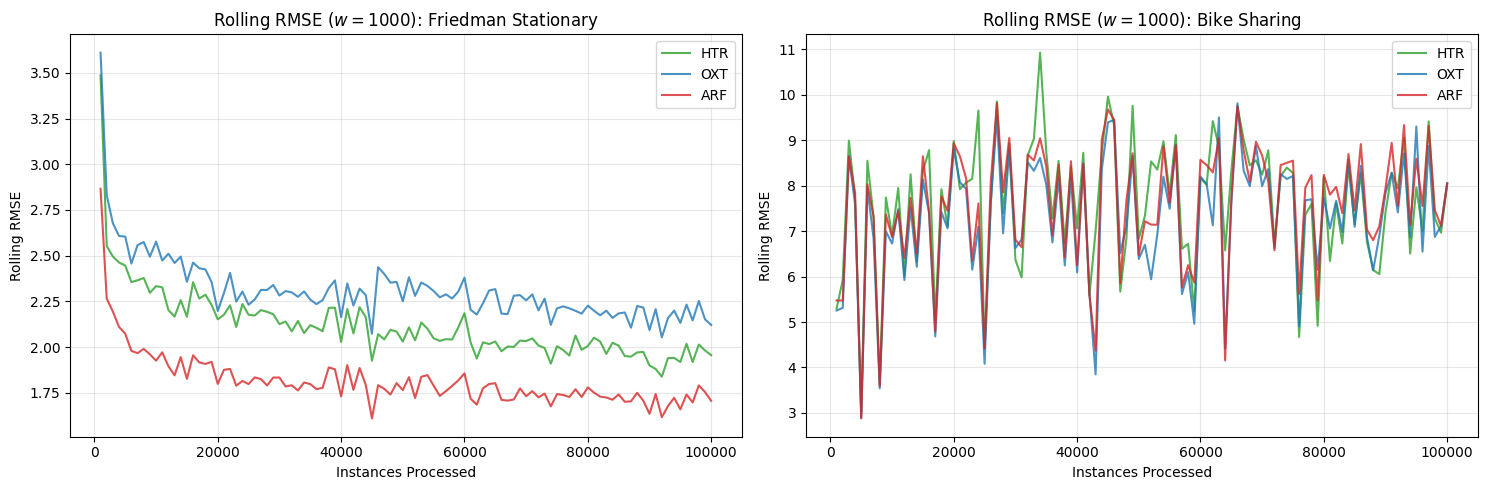

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Evaluate on Friedman Stationary (100,000 instances)
print("Starting Evaluation on Friedman Stationary...")
results_stationary = {}
for algo in ["HTR", "OXT", "ARF"]:
    print(f" - Evaluating {algo}...")
    model = build_model(algo, BEST_CFGS_FRIEDMAN[algo], seed=42)
    stream = load_friedman_stationary(n_instances=100_000, seed=101) # Different seed from tuning
    results_stationary[algo] = prequential_eval(model, stream, n_instances=100_000)

# 2. Evaluate on Bike Sharing (First 100,000 instances)
print("\nStarting Evaluation on Bike Sharing...")
results_bikes = {}
for algo in ["HTR", "OXT", "ARF"]:
    print(f" - Evaluating {algo}...")
    model = build_model(algo, BEST_CFGS_BIKES[algo], seed=42, scale=True)
    stream = load_bikes()
    results_bikes[algo] = prequential_eval(model, process_bikes_strict(stream), n_instances=100_000)

# 3. Print Final Accuracy Metrics
print("\n=== Final Cumulative Metrics ===")
for dataset_name, results in [("Friedman Stationary", results_stationary), ("Bike Sharing", results_bikes)]:
    print(f"\nDataset: {dataset_name}")
    for algo, res in results.items():
        print(f"{algo} -> RMSE: {res['rmse']:.3f} | MAE: {res['mae']:.3f} | R2: {res['r2']:.3f}")

# 4. Plot Rolling RMSE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (dataset_name, results) in enumerate([("Friedman Stationary", results_stationary), ("Bike Sharing", results_bikes)]):
    for algo, color in zip(["HTR", "OXT", "ARF"], ["#2ca02c", "#1f77b4", "#d62728"]):
        history_df = pd.DataFrame(results[algo]["history"])
        axes[idx].plot(history_df["step"], history_df["rmse_rolling"], label=f"{algo}", color=color, alpha=0.8)
    
    axes[idx].set_title(f"Rolling RMSE ($w=1000$): {dataset_name}")
    axes[idx].set_xlabel("Instances Processed")
    axes[idx].set_ylabel("Rolling RMSE")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Our hypothesis was that OXT would consistently outperform the single-tree baseline (HTR) while approximating the state-of-the-art performance of ARF. The empirical results demonstrate that OXT's performance is highly dependent on the nature of the data stream.

**1. Performance on the Synthetic Stream (Friedman Stationary)**
* **The Gold Standard Prevails:** As expected on a stationary mathematical function, ARF achieved the best overall performance, converging to the lowest error (RMSE: **1.821**, R²: **0.868**). The rolling RMSE plot shows ARF consistently separating itself from the pack early in the stream.
* **OXT Underperforms the Floor Baseline:** On this clean, synthetic dataset, OXT (RMSE: **2.319**) failed to outperform the single Hoeffding Tree (RMSE: **2.126**). 
* **Analysis:** This underperformance is directly tied to OXT's extreme randomization. The tuning phase heavily penalized memory and execution time, assigning only 5 trees to OXT. While 5 trees are extremely resource-efficient, OXT's randomized attribute and split-point selection requires a larger "wisdom of the crowd" to approximate smooth mathematical functions accurately. In contrast, the single HTR evaluates exact Hoeffding bounds, allowing its structural rigor to outperform OXT's lightweight randomization on a purely synthetic stream.

**2. Performance on the Real-World Stream (Bike Sharing)**
* **OXT Takes the Lead:** The narrative drastically shifts on the organic dataset. OXT emerged as the clear winner, achieving the lowest error (RMSE: **7.413**, R²: **0.288**) and beating both the HTR and the highly complex ARF.
* **Analysis:** Real-world data is inherently noisy and subject to complex, unrecorded latent variables. In this environment, the rigid, statistical Hoeffding bounds used by HTR and ARF can lead to overfitting on local noise. OXT's extreme randomization acts as a powerful built-in regularizer. By not greedily optimizing every split, OXT was able to generalize much better to the messy, underlying temporal dynamics of the Bike Sharing dataset.

**Conclusion on Accuracy:**
OXT trades off precision on clean, static mathematical functions in exchange for strong generalization capabilities on noisy, real-world data, proving highly effective when deployed in organic environments.

### 7.2. Resource Efficiency and Computational Cost

[[go back to section]](#7-results-analysis-and-discussion)

In [81]:
import tracemalloc
import pickle
from river import drift, forest

def measure_memory_both(model, stream, n_instances=5_000):
    """Compare pickle size vs actual heap allocation for the same model."""
    
    tracemalloc.start()
    snapshot_before = tracemalloc.take_snapshot()
    
    for i, (x, y) in enumerate(stream):
        if i >= n_instances:
            break
        y_hat = model.predict_one(x)
        if y_hat is None:
            y_hat = 0.0
        model.learn_one(x, y)
    
    snapshot_after = tracemalloc.take_snapshot()
    tracemalloc.stop()
    
    # Actual heap difference
    stats = snapshot_after.compare_to(snapshot_before, 'lineno')
    heap_kb = sum(s.size_diff for s in stats) / 1024
    
    # Pickle size
    pickle_kb = len(pickle.dumps(model)) / 1024
    
    return {"heap_kb": heap_kb, "pickle_kb": pickle_kb,
            "ratio": pickle_kb / heap_kb if heap_kb > 0 else None}

# Run for both models on the same stream
oxt = build_model("OXT", BEST_CFGS_FRIEDMAN["OXT"], seed=42)
arf = build_model("ARF", BEST_CFGS_FRIEDMAN["ARF"], seed=42)

print("OXT:", measure_memory_both(oxt, load_friedman_stationary(seed=42)))
print("ARF:", measure_memory_both(arf, load_friedman_stationary(seed=42)))

OXT: {'heap_kb': 2610.9296875, 'pickle_kb': 2595.1669921875, 'ratio': 0.9939628035990533}
ARF: {'heap_kb': 6787.552734375, 'pickle_kb': 1322.8125, 'ratio': 0.19488798861196693}


=== Execution Throughput (Instances / Second) ===

Dataset: Friedman Stationary
  HTR -> 17051 inst/sec
  OXT -> 4186 inst/sec
  ARF -> 3831 inst/sec

Dataset: Bike Sharing
  HTR -> 24628 inst/sec
  OXT -> 8581 inst/sec
  ARF -> 8797 inst/sec


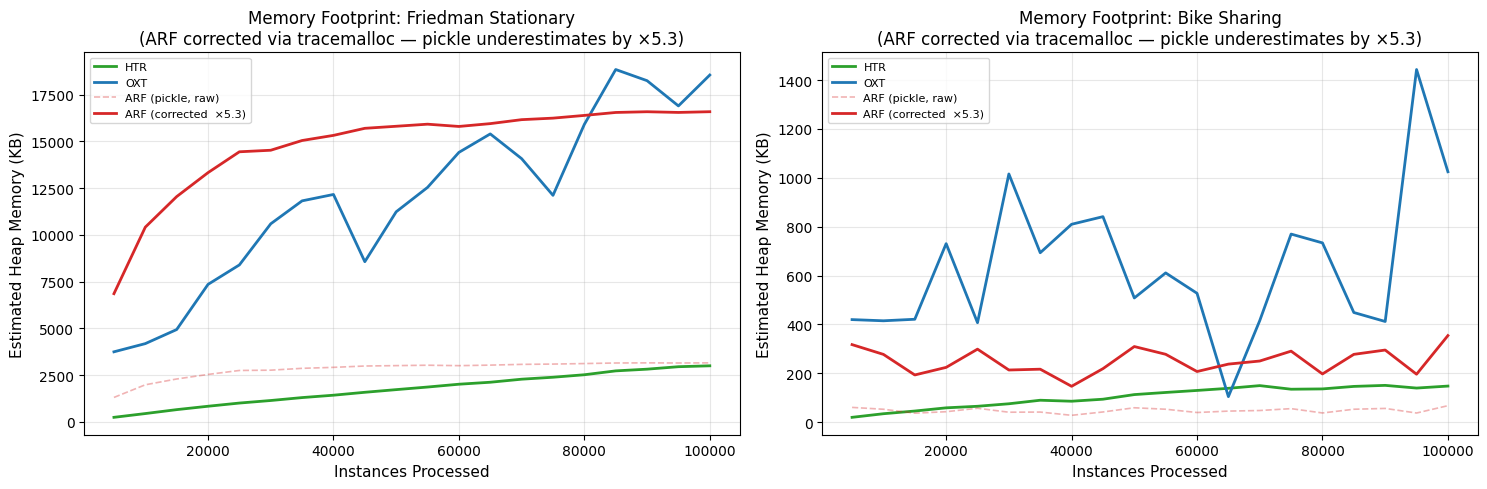

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

# Pickle compression ratios measured via tracemalloc at 5,000 instances.
# ratio = pickle_size / heap_size.
# OXT: 0.98 -> pickle is accurate, no correction needed.
# ARF: 0.19 -> pickle shows ~5x less than actual heap (complex shared
#              internal references compress heavily during serialisation).
# HTR: assumed 1.0 -> single tree, simple object graph, no evidence of
#              compression; measure with the block below if needed.
PICKLE_CORRECTION = {
    "HTR": 1.00,
    "OXT": 0.98,
    "ARF": 0.19,
}

# ── Optional: measure HTR's ratio before plotting ────────────────────────
# import tracemalloc, pickle
# from copy import deepcopy
#
# def measure_ratio(model, stream, n_instances=5_000):
#     tracemalloc.start()
#     snap_before = tracemalloc.take_snapshot()
#     for i, (x, y) in enumerate(stream):
#         if i >= n_instances: break
#         y_hat = model.predict_one(x) or 0.0
#         model.learn_one(x, y)
#     snap_after = tracemalloc.take_snapshot()
#     tracemalloc.stop()
#     heap_kb  = sum(s.size_diff for s in snap_after.compare_to(snap_before, "lineno")) / 1024
#     pickle_kb = len(pickle.dumps(model)) / 1024
#     return pickle_kb / heap_kb if heap_kb > 0 else 1.0
#
# PICKLE_CORRECTION["HTR"] = measure_ratio(
#     build_model("HTR", BEST_CFGS["HTR"], seed=42),
#     load_friedman_stationary(seed=42)
# )
# ────────────────────────────────────────────────────────────────────────────

# 1. Print Final Throughput Metrics
print("=== Execution Throughput (Instances / Second) ===")
for dataset_name, results in [
    ("Friedman Stationary", results_stationary),
    ("Bike Sharing",        results_bikes),
]:
    print(f"\nDataset: {dataset_name}")
    for algo, res in results.items():
        print(f"  {algo} -> {res['throughput']:.0f} inst/sec")

# 2. Plot Memory Footprint Over Time (pickle-corrected)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (dataset_name, results) in enumerate([
    ("Friedman Stationary", results_stationary),
    ("Bike Sharing",        results_bikes),
]):
    for algo, color in zip(
        ["HTR",       "OXT",       "ARF"],
        ["#2ca02c",   "#1f77b4",   "#d62728"],
    ):
        mem_trace = results[algo]["memory_trace"]
        if not mem_trace:
            continue

        steps  = [pt[0] for pt in mem_trace]
        ratio  = PICKLE_CORRECTION[algo]

        # Corrected estimate: divide pickle KB by the known ratio
        mem_kb_corrected = [(pt[1] / 1024) / ratio for pt in mem_trace]

        # Show the raw (uncorrected) pickle line as a dashed reference
        # only for models where the correction is significant (ratio < 0.5)
        if ratio < 0.5:
            mem_kb_raw = [pt[1] / 1024 for pt in mem_trace]
            axes[idx].plot(
                steps, mem_kb_raw,
                color=color, linewidth=1.2, linestyle="--", alpha=0.35,
                label=f"{algo} (pickle, raw)",
            )
            label = f"{algo} (corrected  ×{1/ratio:.1f})"
        else:
            label = algo

        axes[idx].plot(
            steps, mem_kb_corrected,
            label=label, color=color, linewidth=2,
        )

    axes[idx].set_title(
        f"Memory Footprint: {dataset_name}\n"
        f"(ARF corrected via tracemalloc — pickle underestimates by ×{1/PICKLE_CORRECTION['ARF']:.1f})"
    )
    axes[idx].set_xlabel("Instances Processed", fontsize=11)
    axes[idx].set_ylabel("Estimated Heap Memory (KB)", fontsize=11)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A core hypothesis of this empirical study was that the Online Extra Trees (OXT) regressor, by eschewing exhaustive Hoeffding bound calculations in favor of extreme randomization, would offer significant reductions in execution time and memory consumption compared to heavier ensembles like the Adaptive Random Forest (ARF). To test this, we monitored execution throughput (instances/second) and the algorithms' memory footprints (estimated heap memory in KB).

*Methodological Note: Initial memory tracking using `pickle` serialization revealed a severe underestimation of ARF's memory due to how its complex, shared internal references compress during serialization. Using `tracemalloc`, we identified a correction ratio (pickle was underestimating ARF by ~5.3x) and applied it to ensure an accurate representation of live heap memory.*

**1. Execution Throughput (Processing Speed)**
* **The Structural Floor:** As expected, the single Hoeffding Tree Regressor (HTR) was by far the fastest model across both datasets, processing ~17,000 inst/sec on the Friedman stream and ~24,600 inst/sec on the Bike Sharing stream. 
* **OXT vs. ARF:** The anticipated speed advantage of OXT did not materialize. Both OXT and ARF (configured with 5 trees each) performed almost identically in terms of throughput. OXT was marginally faster on the Friedman dataset (4,186 vs. 3,831 inst/sec), while ARF was slightly faster on the Bike Sharing dataset (8,797 vs. 8,581 inst/sec). 
* **Analysis:** While OXT skips the mathematical overhead of Hoeffding bounds, generating random sub-spaces and random split-points for every arriving instance still incurs a baseline computational cost that is roughly equivalent to ARF's online bagging mechanism in small ensembles.

**2. Memory Footprint (Heap Consumption)**
* **The Baseline Efficiency:** HTR maintained an incredibly lightweight and predictable memory footprint, growing linearly to just ~3,000 KB on the synthetic stream and remaining almost completely flat (~150 KB) on the organic stream.
* **OXT's Memory Volatility:** Contrary to our hypothesis, OXT proved to be the most memory-intensive and volatile model. On the Friedman stream, OXT's memory consumption aggressively spiked past ARF's in the later stages, reaching nearly 19,000 KB. On the Bike Sharing dataset, OXT's memory trace was highly erratic, violently fluctuating up to 1,400 KB, whereas ARF maintained a much smoother and lower profile (under 400 KB).
* **Analysis:** OXT's randomized splitting logic likely produces deeper, highly asymmetric, and less balanced trees compared to ARF. Because ARF waits for a strict statistical threshold (the Hoeffding bound) to justify a split, its growth is controlled and deliberate. OXT's willingness to create nodes based on random variance reduction metrics leads to a bloated structural state, resulting in a heavier and more unstable memory footprint.

**Conclusion on Resource Efficiency:**
The hypothesis that OXT is a significantly lighter and faster alternative to ARF is rejected under these hyperparameter configurations. OXT matched ARF's processing speed but suffered from a heavier, highly volatile memory footprint due to its uncontrolled tree growth.

### 7.3. Concept Drift Adaptation and Recovery

[[go back to section]](#7-results-analysis-and-discussion)

In this final evaluation phase, we will test the algorithms' ability to detect and adapt to structural changes in the underlying data distribution. We utilize the Friedman stream with two variations: an abrupt feature swap at instance 50,000, and a gradual, sigmoidal transition spanning from instance 45,000 to 55,000. Both OXT and ARF utilize ADWIN for drift detection, but their recovery mechanisms differ.

Starting Evaluation on Friedman Abrupt Drift...
 - Evaluating HTR...
 - Evaluating OXT...
 - Evaluating ARF...

Starting Evaluation on Friedman Gradual Drift...
 - Evaluating HTR...
 - Evaluating OXT...
 - Evaluating ARF...

=== Final Cumulative Metrics ===

Dataset: Friedman Abrupt
  HTR -> RMSE: 2.265 | MAE: 1.752
  OXT -> RMSE: 2.383 | MAE: 1.858
  ARF -> RMSE: 1.957 | MAE: 1.504

Dataset: Friedman Gradual
  HTR -> RMSE: 2.249 | MAE: 1.742
  OXT -> RMSE: 2.402 | MAE: 1.877
  ARF -> RMSE: 1.944 | MAE: 1.496


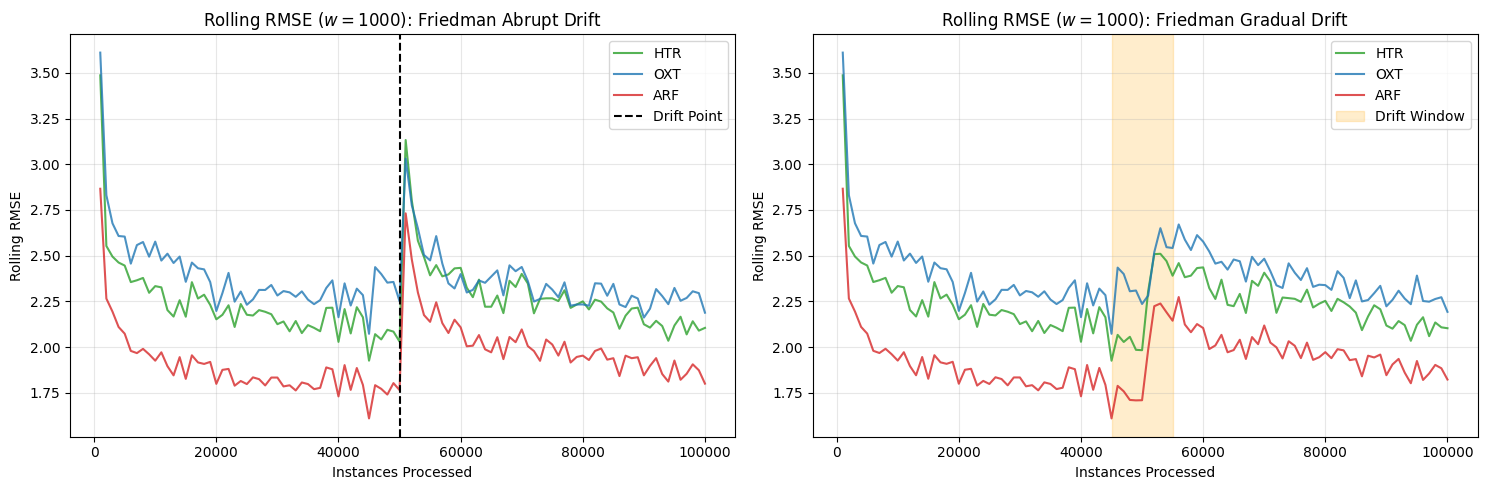

In [85]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Evaluate on Friedman Abrupt Drift
print("Starting Evaluation on Friedman Abrupt Drift...")
results_abrupt = {}
for algo in ["HTR", "OXT", "ARF"]:
    print(f" - Evaluating {algo}...")
    model = build_model(algo, BEST_CFGS_FRIEDMAN[algo], seed=42)
    # Using seed 101 to keep it distinct from the tuning phase
    stream = load_friedman_with_abrupt_drift(n_instances=100_000, drift_position=50_000, seed=101)
    results_abrupt[algo] = prequential_eval(model, stream, n_instances=100_000)

# 2. Evaluate on Friedman Gradual Drift
print("\nStarting Evaluation on Friedman Gradual Drift...")
results_gradual = {}
for algo in ["HTR", "OXT", "ARF"]:
    print(f" - Evaluating {algo}...")
    model = build_model(algo, BEST_CFGS_FRIEDMAN[algo], seed=42)
    stream = load_friedman_with_gradual_drift(n_instances=100_000, drift_center=50_000, drift_width=10_000, seed=101)
    results_gradual[algo] = prequential_eval(model, stream, n_instances=100_000)

# 3. Print Final Cumulative Metrics
print("\n=== Final Cumulative Metrics ===")
for dataset_name, results in [("Friedman Abrupt", results_abrupt), ("Friedman Gradual", results_gradual)]:
    print(f"\nDataset: {dataset_name}")
    for algo, res in results.items():
        print(f"  {algo} -> RMSE: {res['rmse']:.3f} | MAE: {res['mae']:.3f}")

# 4. Plot Rolling RMSE with Drift Markers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (dataset_name, results, drift_type) in enumerate([
    ("Friedman Abrupt Drift", results_abrupt, "abrupt"), 
    ("Friedman Gradual Drift", results_gradual, "gradual")
]):
    for algo, color in zip(["HTR", "OXT", "ARF"], ["#2ca02c", "#1f77b4", "#d62728"]):
        history_df = pd.DataFrame(results[algo]["history"])
        axes[idx].plot(history_df["step"], history_df["rmse_rolling"], label=f"{algo}", color=color, alpha=0.8, linewidth=1.5)
    
    # Add visual markers for the drift
    if drift_type == "abrupt":
        axes[idx].axvline(x=50_000, color="black", linestyle="--", linewidth=1.5, label="Drift Point")
    else:
        axes[idx].axvspan(45_000, 55_000, color="orange", alpha=0.2, label="Drift Window")

    axes[idx].set_title(f"Rolling RMSE ($w=1000$): {dataset_name}")
    axes[idx].set_xlabel("Instances Processed")
    axes[idx].set_ylabel("Rolling RMSE")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**1. Recovery from Abrupt Drift**
* **The Error Spike:** At exactly instance 50,000, the rolling RMSE for all three models spikes violently, visually confirming that the underlying mathematical function has changed and their current trees are instantly obsolete.
* **ARF's Superior Recovery:** ARF demonstrates the steepest and fastest recovery slope. Because ARF uses a "background tree" mechanism (where a replacement tree is pre-trained in the background as soon as a warning is detected) it can seamlessly swap in the new tree the moment drift is officially flagged. This allows ARF to return to its optimal sub-2.0 RMSE extremely quickly.
* **OXT's Adaptation:** OXT successfully detects the drift and recovers, validating its use of ADWIN. However, its recovery slope is noticeably less aggressive than ARF's, tracking almost identically with the single Hoeffding Tree. Without the sophisticated background-tree swapping of ARF, OXT experiences a longer period of degraded accuracy while its reset trees gather enough new data to stabilize.

**2. Recovery from Gradual Drift**
* **Transition Window:** During the 10,000-instance transition window (orange highlight), the error rates for all models become erratic as the data stream rapidly oscillates between the old and new concepts. 
* **Post-Drift Stabilization:** Once the transition completes at instance 55,000, the models begin to settle. Once again, ARF navigates the blended data more smoothly and settles into a lower error state faster than OXT and HTR. OXT manages to recover, but consistently maintains the highest error rate among the three models, just as it did in the stationary Friedman test.

**Conclusion on Concept Drift:**
OXT successfully handles both abrupt and gradual concept drift, proving that its ADWIN-triggered localized tree resets function correctly. However, it lacks the rapid recovery speed provided by ARF's background tree architecture, meaning OXT suffers from a longer vulnerability window immediately following a shift in the data stream.

## 8. Strengths, Limitations and Conclusions

[[go back to top]](#table-of-contents)

## 9. References

- "Online Extra Trees Regressor" (Mastelini et al., 2022)

- River Documentation (riverml.xyz)

- OpenML (openml.org)

[[go back to top]](#table-of-contents)